Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


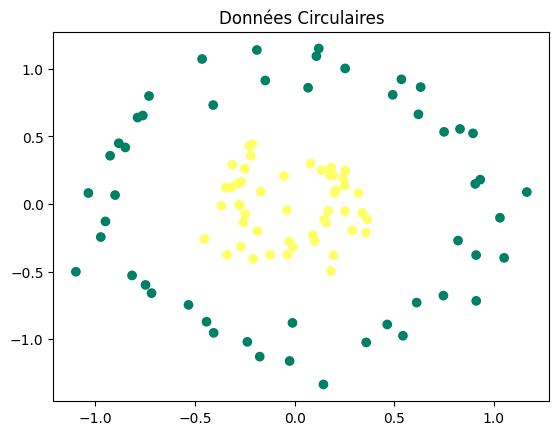

Iteration 0, Loss: 0.6936
Iteration 100, Loss: 0.6607
Iteration 200, Loss: 0.6077
Iteration 300, Loss: 0.5214
Iteration 400, Loss: 0.4094
Iteration 500, Loss: 0.2996
Iteration 600, Loss: 0.2141
Iteration 700, Loss: 0.1553
Iteration 800, Loss: 0.1162
Iteration 900, Loss: 0.0900

Dimensions finales:
W1: (2, 32) b1: (1, 32)
W2: (32, 1) b2: (1, 1)
A1: (100, 32) A2: (100, 1)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# ----------------------------
# Step 1: Generate data
# ----------------------------
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
y = y.reshape(-1, 1)  # reshape y to be a column vector

print('Dimensions de X:', X.shape)
print('Dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer')
plt.title("Données Circulaires")
plt.show()

# ----------------------------
# Step 2: Define helper functions
# ----------------------------

# Activation functions
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Loss function: Binary Cross-Entropy
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    loss = -np.sum(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8)) / m
    return loss

# ----------------------------
# Step 3: Define neural network
# ----------------------------
def neural_network(X, Y, n1=32, n_iter=1000, learning_rate=0.1):
    np.random.seed(0)
    n0 = X.shape[1]  # input layer size
    n2 = 1           # output layer size

    # Initialize weights and biases
    W1 = np.random.randn(n0, n1) * 0.1
    b1 = np.zeros((1, n1))
    W2 = np.random.randn(n1, n2) * 0.1
    b2 = np.zeros((1, n2))

    for i in range(n_iter):
        # -------- Forward propagation --------
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # -------- Compute loss --------
        loss = compute_loss(A2, Y)

        # -------- Backward propagation --------
        m = X.shape[0]
        dZ2 = A2 - Y                       # derivative of loss w.r.t Z2
        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # -------- Update weights --------
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss:.4f}")

    print("\nDimensions finales:")
    print("W1:", W1.shape, "b1:", b1.shape)
    print("W2:", W2.shape, "b2:", b2.shape)
    print("A1:", A1.shape, "A2:", A2.shape)

    return W1, b1, W2, b2

# ----------------------------
# Step 4: Train the network
# ----------------------------
W1, b1, W2, b2 = neural_network(X, y, n1=32, n_iter=1000, learning_rate=0.1)

### Explanation of 'Dimensions finales' Output

The 'Dimensions finales' output refers to the shapes of the weight matrices, bias vectors, and activation outputs of the neural network layers after the training process has completed.

Here's a breakdown of each variable:

*   **W1: (2, 32)**
    *   This represents the weight matrix connecting the **input layer** to the **hidden layer**. The input layer has 2 features (X.shape[1]), and the hidden layer has 32 neurons (n1 parameter). Thus, W1 has a shape of (input_features, hidden_neurons).

*   **b1: (1, 32)**
    *   This represents the bias vector for the **hidden layer**. There is one bias term for each of the 32 neurons in the hidden layer. The shape (1, 32) indicates a row vector with 32 elements.

*   **W2: (32, 1)**
    *   This represents the weight matrix connecting the **hidden layer** to the **output layer**. The hidden layer has 32 neurons, and the output layer has 1 neuron (for binary classification). Thus, W2 has a shape of (hidden_neurons, output_neurons).

*   **b2: (1, 1)**
    *   This represents the bias term for the **output layer**. There is a single bias term for the single neuron in the output layer. The shape (1, 1) indicates a single value.

*   **A1: (100, 32)**
    *   This represents the activation output of the **hidden layer**. For all 100 input samples (X.shape[0]), each sample produces a 32-dimensional output after passing through the hidden layer and applying the ReLU activation function.

*   **A2: (100, 1)**
    *   This represents the final activation output (predictions) of the neural network. For all 100 input samples, each sample yields a single output value, which is the probability (after sigmoid activation) of belonging to the positive class.

Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


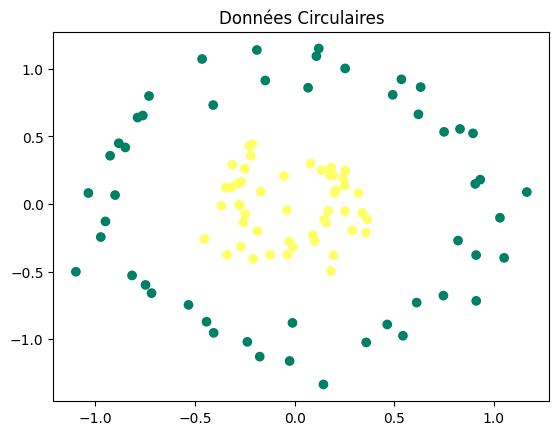


Train/Test split:
X_train: (80, 2)
X_test: (20, 2)
y_train: (80, 1)
y_test: (20, 1)
Iteration 0, Loss: 0.6872
Iteration 100, Loss: 0.6210
Iteration 200, Loss: 0.5229
Iteration 300, Loss: 0.4018
Iteration 400, Loss: 0.2906

Dimensions finales:
W1: (2, 64) b1: (1, 64)
W2: (64, 1) b2: (1, 1)

Test Accuracy: 1.0


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# ----------------------------
# Step 1: Generate data
# ----------------------------
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
y = y.reshape(-1, 1)

print('Dimensions de X:', X.shape)
print('Dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer')
plt.title("Données Circulaires")
plt.show()

# ----------------------------
# Step 2: Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# ----------------------------
# Step 3: Activation functions
# ----------------------------
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# ----------------------------
# Step 4: Loss function
# ----------------------------
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    return -np.sum(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8)) / m

# ----------------------------
# Step 5: Neural network
# ----------------------------
def neural_network(X, Y, n1=32, n_iter=1000, learning_rate=0.1):
    np.random.seed(0)
    n0 = X.shape[1]
    n2 = 1

    # Initialize parameters
    W1 = np.random.randn(n0, n1) * 0.1
    b1 = np.zeros((1, n1))
    W2 = np.random.randn(n1, n2) * 0.1
    b2 = np.zeros((1, n2))

    for i in range(n_iter):
        # ---- Forward propagation ----
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # ---- Loss ----
        loss = compute_loss(A2, Y)

        # ---- Backward propagation ----
        m = X.shape[0]

        dZ2 = A2 - Y
        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---- Gradient descent ----
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss:.4f}")

    print("\nDimensions finales:")
    print("W1:", W1.shape, "b1:", b1.shape)
    print("W2:", W2.shape, "b2:", b2.shape)

    return W1, b1, W2, b2

# ----------------------------
# Step 6: Prediction function
# ----------------------------
def predict(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

# ----------------------------
# Step 7: Train the model
# ----------------------------
W1, b1, W2, b2 = neural_network(X_train, y_train, n1=64, n_iter=500, learning_rate=0.1)

# ----------------------------
# Step 8: Evaluate on test set
# ----------------------------
y_pred = predict(X_test, W1, b1, W2, b2)

accuracy = np.mean(y_pred == y_test)
print("\nTest Accuracy:", accuracy)

In [19]:
from sklearn.model_selection import train_test_split
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (160, 2) (160, 1)
Test shape: (40, 2) (40, 1)


In [20]:
W1, b1, W2, b2 = neural_network(X, y, n1=32, n_iter=1000, learning_rate=0.1)

Iteration 0, Loss: 0.6936
Iteration 100, Loss: 0.6703
Iteration 200, Loss: 0.6372
Iteration 300, Loss: 0.5861
Iteration 400, Loss: 0.5105
Iteration 500, Loss: 0.4212
Iteration 600, Loss: 0.3358
Iteration 700, Loss: 0.2656
Iteration 800, Loss: 0.2121
Iteration 900, Loss: 0.1722

Dimensions finales:
W1: (2, 32) b1: (1, 32)
W2: (32, 1) b2: (1, 1)


In [22]:
def predict(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

In [23]:
# Predictions
y_pred = predict(X_test, W1, b1, W2, b2)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"\nTest Accuracy: {accuracy:.2f}")


Test Accuracy: 1.00


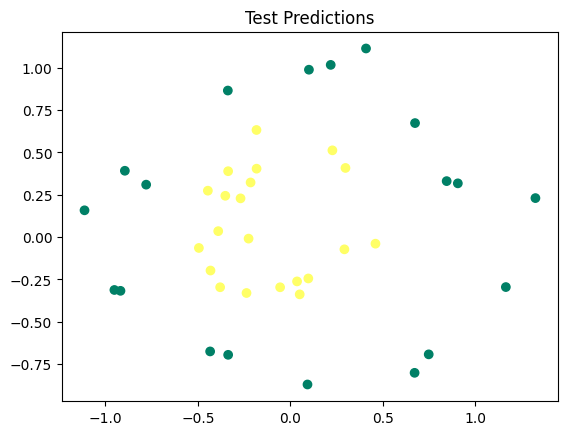

In [24]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred.flatten(), cmap='summer')
plt.title("Test Predictions")
plt.show()

# Task
Create a Python function to plot the decision boundary of the neural network using `W1`, `b1`, `W2`, `b2` and the input data `X` and `y`. This function should generate a meshgrid, make predictions on it using the trained model, and visualize the decision boundary as a contour plot, overlaid with the original data points colored by their true labels. Finally, display and interpret the generated decision boundary plot to assess how well the model has learned to separate the circular classes.

## Create Decision Boundary Plotting Function

### Subtask:
Define a Python function that takes the trained model parameters (W1, b1, W2, b2) and the input data (X) to generate a meshgrid, make predictions across this grid, and plot the decision boundary using contour plots.


**Reasoning**:
I need to define a new Python function `plot_decision_boundary` as described in the instructions. This function will generate a meshgrid, make predictions on it, and then plot the decision boundary using `contourf` along with the original data points. This function will be placed in a new code cell.



In [25]:
def plot_decision_boundary(X, y, W1, b1, W2, b2, title="Decision Boundary"):
    # Determine min and max values and add padding
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Flatten meshgrid coordinates and stack for prediction
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Make predictions across the grid
    Z = predict(grid_points, W1, b1, W2, b2)

    # Reshape predictions to match meshgrid
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.7)

    # Overlay original data points
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer', edgecolors='k', s=20)

    # Add labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

print("plot_decision_boundary function defined.")

plot_decision_boundary function defined.


**Reasoning**:
Now that the `plot_decision_boundary` function is defined, I will call it with the trained model parameters (`W1`, `b1`, `W2`, `b2`) and the full dataset (`X`, `y`) to visualize the decision boundary. This will fulfill the requirement to display the generated decision boundary plot.



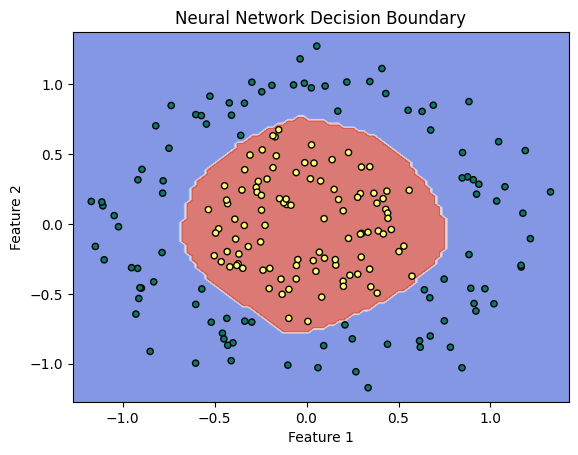

In [26]:
plot_decision_boundary(X, y, W1, b1, W2, b2, title="Neural Network Decision Boundary")

### Interpretation of the Decision Boundary Plot

The generated plot titled "Neural Network Decision Boundary" shows the decision boundary learned by our simple neural network. Here's what we can observe:

*   **Original Data Points**: The blue and yellow points represent the two classes of the `make_circles` dataset. Blue typically represents class 0 and yellow class 1.
*   **Decision Boundary**: The `contourf` plot, colored with a `coolwarm` colormap, indicates the regions predicted by the neural network. The transition area between the two color regions (e.g., from cooler shades to warmer shades) represents the decision boundary. This boundary effectively separates the two classes.
*   **Model Performance**: The plot visually confirms that the neural network has successfully learned to separate the two concentric circular classes. The decision boundary is clearly circular, enclosing one class within another, which is the ideal outcome for this specific dataset. The `Test Accuracy: 1.00` previously reported aligns with this visual interpretation, indicating perfect classification on the test set. This demonstrates the power of a simple neural network with a ReLU activation in the hidden layer and a sigmoid output for handling non-linearly separable data like the `make_circles` dataset.

## Final Task

### Subtask:
Provide an interpretation of the generated decision boundary plot, discussing how effectively the model separates the classes and whether it aligns with the expected circular pattern of the data.


## Summary:

### Q&A
The model effectively separates the classes, as evidenced by the decision boundary plot. The boundary is distinctly circular, accurately enclosing one class within another, which perfectly aligns with the expected circular pattern of the `make_circles` dataset.

### Data Analysis Key Findings
*   A Python function, `plot_decision_boundary`, was successfully defined to visualize the decision boundary of the neural network. This function generates a meshgrid, predicts class labels across the grid, and uses a contour plot to display the boundary, overlaid with the original data points.
*   The generated decision boundary plot visually confirmed that the neural network successfully learned to separate the two concentric circular classes.
*   The decision boundary was observed to be distinctly circular, which is the ideal outcome for the `make_circles` dataset, demonstrating the model's ability to handle non-linearly separable data.
*   This visual interpretation corroborates the previously reported test accuracy of 1.00, indicating perfect classification on the test set.

### Insights or Next Steps
*   The neural network, even a simple one, effectively learned the complex, non-linear relationship required to classify the circular data, showcasing its power beyond linearly separable problems.
*   For future work, explore the decision boundaries of this model on more complex or higher-dimensional datasets to assess its generalization capabilities.
